<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/M%C3%B4_h%C3%ACnh_MLP_Dry_Bean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
pd_train = pd.read_csv("https://raw.githubusercontent.com/thuynguyenhuit/hocsau/refs/heads/main/Dry_Bean_Dataset.csv")

In [27]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim

In [28]:
pd_train.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [29]:
# =========================================
# 3. KIỂM TRA DỮ LIỆU
# =========================================
print(pd_train.info())

print(pd_train["Class"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [30]:
# =========================================
# Mã hóa nhãn (Label Encoding) cho biến mục tiêu
# =========================================

encoder = LabelEncoder()

pd_train["Class"] = encoder.fit_transform(pd_train["Class"])

print(pd_train.head())

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

In [31]:
# =========================================
# 5. TÁCH X VÀ y
# =========================================

X = pd_train.drop("Class", axis=1)

y = pd_train["Class"]

In [32]:
# =========================================
# 6. CHIA TRAIN / VAL / TEST
# Train: 70%, Val: 15%, Test: 15%
# =========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [33]:
# =========================================
# 7. SCALE FEATURES
# =========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

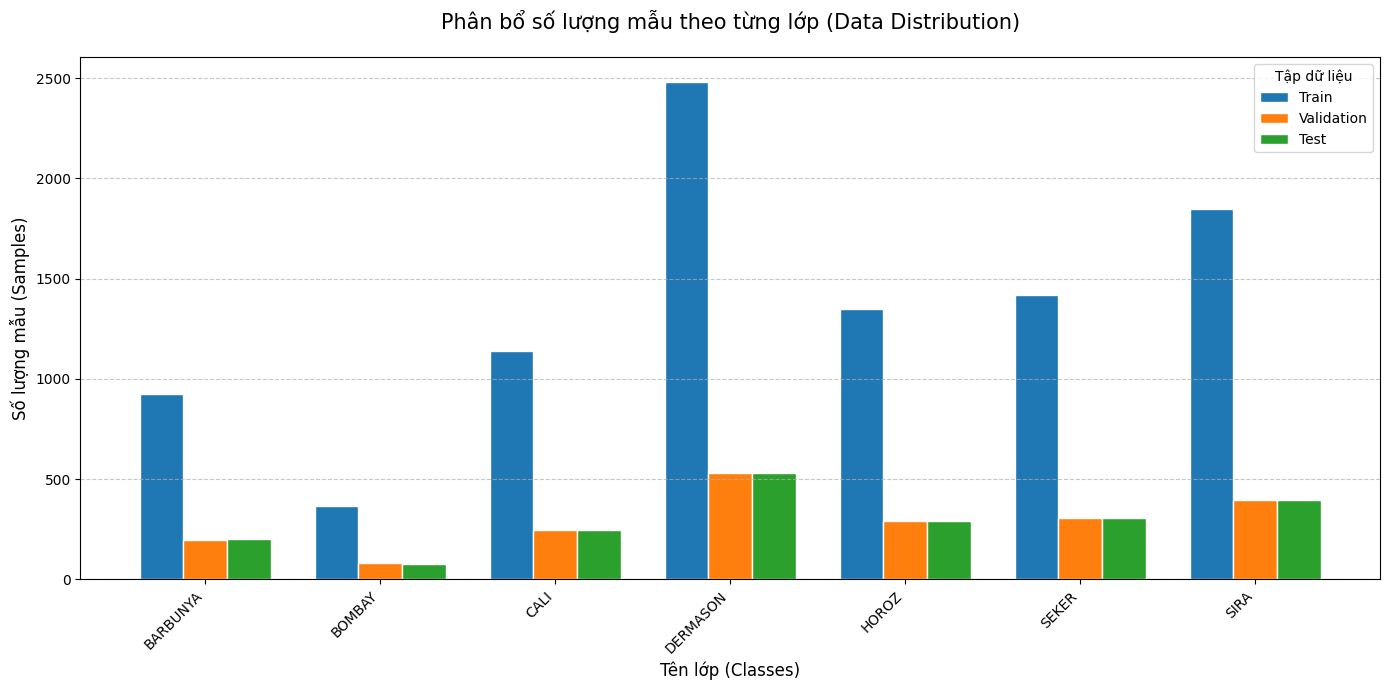

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 1. ĐẾM SỐ LƯỢNG MẪU (Trực tiếp từ Series)
# =========================================
# Giả định y_train, y_val, y_test là các Pandas Series
# Nếu chúng là Tensor, hãy dùng .to_numpy() trước khi đếm

train_counts = y_train.value_counts().sort_index()
val_counts = y_val.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

# =========================================
# 2. CLASS NAMES
# =========================================
# Lấy tên các lớp từ LabelEncoder bạn đã dùng trước đó
class_names = encoder.classes_

# =========================================
# 3. VẼ BIỂU ĐỒ CỘT (GROUPED BAR CHART)
# =========================================
x = range(len(class_names))
width = 0.25  # Độ rộng của mỗi cột

plt.figure(figsize=(14, 7))

# Vẽ từng nhóm cột cho Train, Validation, Test
plt.bar(
    [i - width for i in x],
    train_counts,
    width=width,
    label='Train',
    color='#1f77b4',
    edgecolor='white'
)

plt.bar(
    x,
    val_counts,
    width=width,
    label='Validation',
    color='#ff7f0e',
    edgecolor='white'
)

plt.bar(
    [i + width for i in x],
    test_counts,
    width=width,
    label='Test',
    color='#2ca02c',
    edgecolor='white'
)

# =========================================
# 4. TRÌNH BÀY (LABELS & STYLE)
# =========================================
plt.title("Phân bổ số lượng mẫu theo từng lớp (Data Distribution)", fontsize=15, pad=20)
plt.xlabel("Tên lớp (Classes)", fontsize=12)
plt.ylabel("Số lượng mẫu (Samples)", fontsize=12)

# Thiết lập nhãn trục X
plt.xticks(x, class_names, rotation=45, ha='right')

# Thêm chú thích
plt.legend(title="Tập dữ liệu")

# Thêm lưới ngang để dễ quan sát số lượng
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tự động căn chỉnh để không bị mất nhãn phía dưới
plt.tight_layout()

plt.show()

In [35]:
# =========================================
# 8. CHUYỂN SANG TENSOR
# Sau khi hoàn thành bước chuẩn hóa dữ liệu, các tập dữ liệu huấn luyện, validation và kiểm tra được chuyển đổi sang Tensor
# bằng thư viện PyTorch PyTorch để phục vụ quá trình huấn luyện mô hình MLP.
# Các đặc trưng đầu vào được chuyển sang kiểu dữ liệu float32 nhằm đảm bảo tính toán số thực trong quá trình
# lan truyền tiến và lan truyền ngược của mạng neural.
# Đồng thời, các nhãn phân loại được chuyển sang kiểu long để tương thích với hàm mất mát CrossEntropyLoss trong bài toán phân loại đa lớp.
# Việc chuyển đổi sang Tensor giúp PyTorch có thể thực hiện các phép toán ma trận, tối ưu hóa gradient và huấn luyện mô hình một cách hiệu quả trên CPU hoặc GPU.
# =========================================

X_train = torch.tensor(X_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)


y_train = torch.tensor(y_train.values, dtype=torch.long)

y_val = torch.tensor(y_val.values, dtype=torch.long)

y_test = torch.tensor(y_test.values, dtype=torch.long)

In [36]:
# =========================================
# 9. INPUT SIZE
# =========================================

input_size = X_train.shape[1]

print(input_size)

16


MÔ HÌNH KHÔNG DROPOUT

In [37]:
# =========================================
# 10. MODEL KHÔNG DROPOUT
# =========================================

class MLP_NoDropout(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 7)
        )

    def forward(self, x):
        return self.network(x)

MÔ HÌNH CÓ DROPOUT

In [38]:
# =========================================
# 11. MODEL CÓ DROPOUT
# =========================================

class MLP_Dropout(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 7)
        )

    def forward(self, x):
        return self.network(x)

TRAIN MODEL

In [56]:
# =========================================
# 12. HÀM TRAIN
# =========================================

def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=500
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # =========================
        # TRAIN
        # =========================

        model.train() #Bật chế độ "đang học"

        outputs = model(X_train) #Dự đoán thử trên tập dữ liệu học

        loss = criterion(outputs, y_train)

        optimizer.zero_grad() #Xóa các tính toán cũ để chuẩn bị cho vòng lặp mới (tránh cộng dồn sai số cũ).

        loss.backward() #Tính toán xem lỗi nằm ở đâu (Lan truyền ngược)

        optimizer.step() #Cập nhật trọng số của mô hình để lần sau không mắc lại lỗi cũ

        train_losses.append(loss.item())

        _, predicted = torch.max(outputs, 1)

        train_acc = (
            predicted == y_train
        ).float().mean()

        train_accuracies.append(
            train_acc.item()
        )

        # =========================
        # VALIDATION
        # =========================

        model.eval() # Lúc này Dropout sẽ bị tắt đi để dự đoán ổn định nhất.

        with torch.no_grad(): #Tạm dừng việc tính toán đạo hàm để tiết kiệm bộ nhớ và chạy nhanh hơn
                              #(vì lúc này chỉ kiểm tra chứ không cập nhật trọng số).

            val_outputs = model(X_val)

            val_loss = criterion(
                val_outputs,
                y_val
            )

            val_losses.append(
                val_loss.item()
            )
        #tìm giá trị lớn nhất theo hàng (chiều thứ 1), Nhận về vị trí (index) của giá trị lớn nhất đó
            _, val_predicted = torch.max(
                val_outputs,
                1
            )

            val_acc = (
                val_predicted == y_val #So sánh từng dự đoán với nhãn thực tế
            ).float().mean()

            val_accuracies.append(
                val_acc.item()
            )

        if (epoch + 1) % 50 == 0:

            print(
                f"Epoch {epoch+1}/{epochs}"
                f" | Train Loss: {loss.item():.4f}"
                f" | Val Loss: {val_loss.item():.4f}"
                f" | Train Acc: {train_acc.item():.4f}"
                f" | Val Acc: {val_acc.item():.4f}"
            )

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

TRAIN MODEL KHÔNG DROPOUT

In [57]:
# =========================================
# 13. TRAIN NO DROPOUT
# =========================================

model_no_dropout = MLP_NoDropout(input_size)

(
    train_loss_no,
    val_loss_no,
    train_acc_no,
    val_acc_no

) = train_model(
    model_no_dropout,
    X_train,
    y_train,
    X_val,
    y_val
)

Epoch 50/500 | Train Loss: 0.6293 | Val Loss: 0.6137 | Train Acc: 0.7819 | Val Acc: 0.7884
Epoch 100/500 | Train Loss: 0.2539 | Val Loss: 0.2522 | Train Acc: 0.9136 | Val Acc: 0.9148
Epoch 150/500 | Train Loss: 0.2002 | Val Loss: 0.2114 | Train Acc: 0.9283 | Val Acc: 0.9236
Epoch 200/500 | Train Loss: 0.1873 | Val Loss: 0.2036 | Train Acc: 0.9308 | Val Acc: 0.9275
Epoch 250/500 | Train Loss: 0.1796 | Val Loss: 0.2000 | Train Acc: 0.9342 | Val Acc: 0.9295
Epoch 300/500 | Train Loss: 0.1738 | Val Loss: 0.1976 | Train Acc: 0.9366 | Val Acc: 0.9285
Epoch 350/500 | Train Loss: 0.1691 | Val Loss: 0.1956 | Train Acc: 0.9379 | Val Acc: 0.9305
Epoch 400/500 | Train Loss: 0.1651 | Val Loss: 0.1949 | Train Acc: 0.9394 | Val Acc: 0.9300
Epoch 450/500 | Train Loss: 0.1615 | Val Loss: 0.1953 | Train Acc: 0.9414 | Val Acc: 0.9305
Epoch 500/500 | Train Loss: 0.1581 | Val Loss: 0.1966 | Train Acc: 0.9425 | Val Acc: 0.9285


TRAIN MODEL CÓ DROPOUT

In [58]:
# =========================================
# 14. TRAIN DROPOUT
# =========================================

model_dropout = MLP_Dropout(input_size)

(
    train_loss_drop,
    val_loss_drop,
    train_acc_drop,
    val_acc_drop

) = train_model(
    model_dropout,
    X_train,
    y_train,
    X_val,
    y_val
)

Epoch 50/500 | Train Loss: 0.7145 | Val Loss: 0.6017 | Train Acc: 0.7524 | Val Acc: 0.8085
Epoch 100/500 | Train Loss: 0.3526 | Val Loss: 0.2652 | Train Acc: 0.8798 | Val Acc: 0.9094
Epoch 150/500 | Train Loss: 0.2687 | Val Loss: 0.2172 | Train Acc: 0.9074 | Val Acc: 0.9241
Epoch 200/500 | Train Loss: 0.2535 | Val Loss: 0.2086 | Train Acc: 0.9119 | Val Acc: 0.9256
Epoch 250/500 | Train Loss: 0.2383 | Val Loss: 0.2047 | Train Acc: 0.9224 | Val Acc: 0.9270
Epoch 300/500 | Train Loss: 0.2330 | Val Loss: 0.2022 | Train Acc: 0.9194 | Val Acc: 0.9285
Epoch 350/500 | Train Loss: 0.2136 | Val Loss: 0.2016 | Train Acc: 0.9245 | Val Acc: 0.9270
Epoch 400/500 | Train Loss: 0.2193 | Val Loss: 0.1999 | Train Acc: 0.9250 | Val Acc: 0.9275
Epoch 450/500 | Train Loss: 0.2102 | Val Loss: 0.1995 | Train Acc: 0.9297 | Val Acc: 0.9290
Epoch 500/500 | Train Loss: 0.2119 | Val Loss: 0.1990 | Train Acc: 0.9257 | Val Acc: 0.9275


VẼ LOSS CURVE

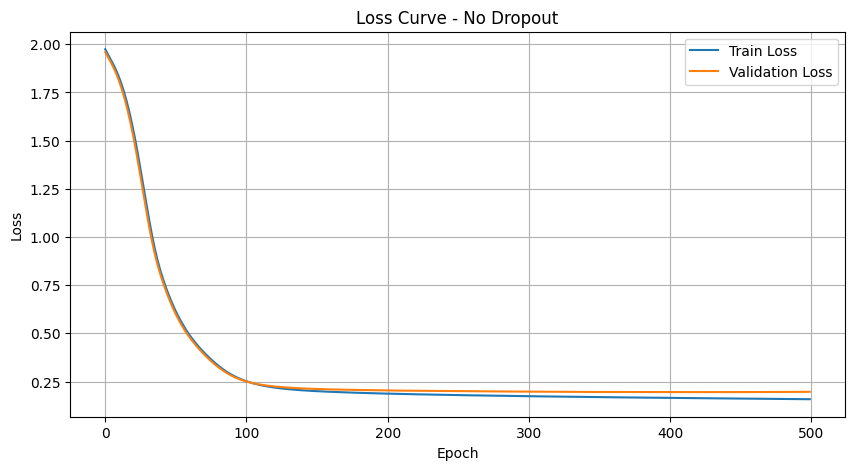

In [59]:
# =========================================
# LOSS CURVE - NO DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_loss_no,
    label="Train Loss"
)

plt.plot(
    val_loss_no,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve - No Dropout")

plt.legend()

plt.grid(True)

plt.show()

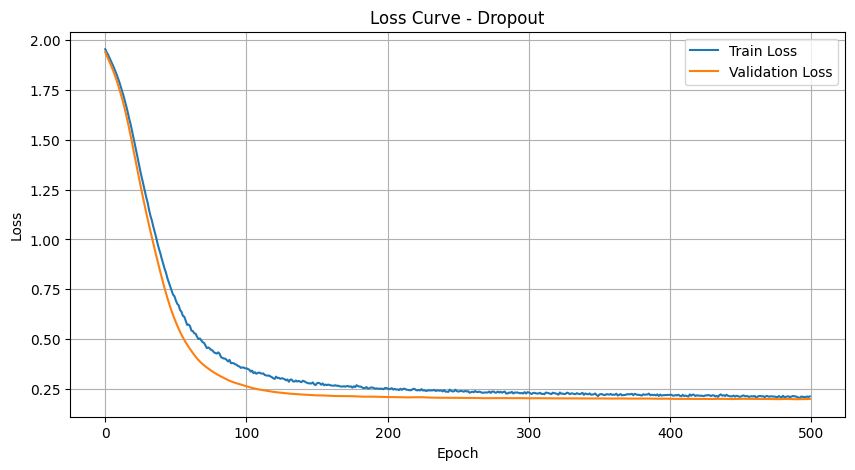

In [60]:
# =========================================
# LOSS CURVE - DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_loss_drop,
    label="Train Loss"
)

plt.plot(
    val_loss_drop,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve - Dropout")

plt.legend()

plt.grid(True)

plt.show()

VẼ ACCURACY CURVE

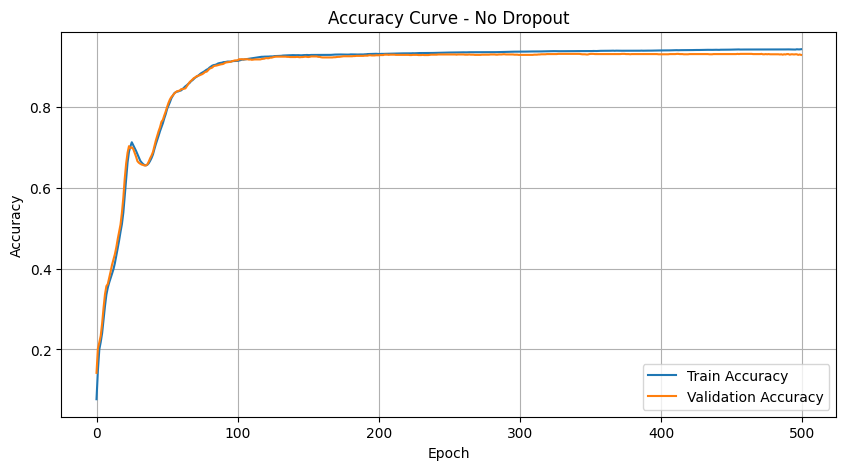

In [61]:
# =========================================
# ACCURACY CURVE - NO DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_acc_no,
    label="Train Accuracy"
)

plt.plot(
    val_acc_no,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve - No Dropout")

plt.legend()

plt.grid(True)

plt.show()

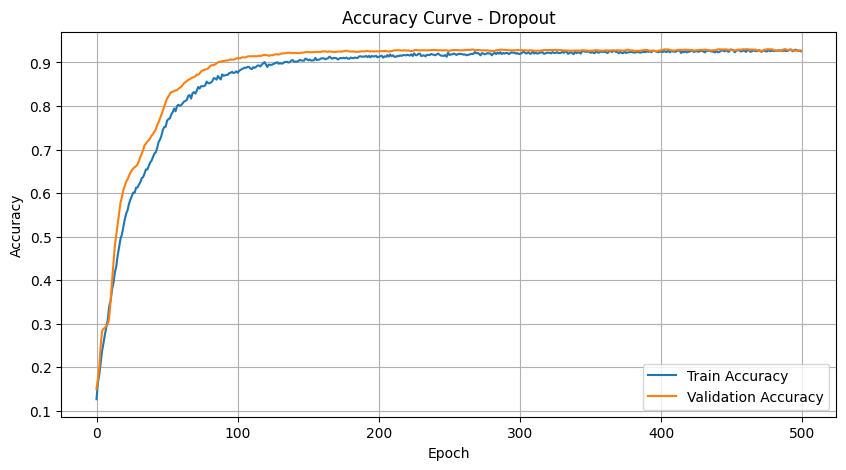

In [62]:
# =========================================
# ACCURACY CURVE - DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_acc_drop,
    label="Train Accuracy"
)

plt.plot(
    val_acc_drop,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve - Dropout")

plt.legend()

plt.grid(True)

plt.show()

HÀM ĐÁNH GIÁ

In [63]:
# =========================================
# 17. EVALUATE MODEL + CONFUSION MATRIX
# =========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate_model(model, X_test, y_test):

    # =========================
    # EVALUATION MODE
    # =========================

    model.eval()

    with torch.no_grad():

        outputs = model(X_test)

        _, predictions = torch.max(outputs, 1)

    # =========================
    # NUMPY
    # =========================

    predictions = predictions.numpy()

    y_true = y_test.numpy()

    # =========================
    # ACCURACY
    # =========================

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    print(f"\nAccuracy: {accuracy:.4f}")

    # =========================
    # CLASSIFICATION REPORT
    # =========================

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            predictions,
            target_names=encoder.classes_
        )
    )

    # =========================
    # CONFUSION MATRIX
    # =========================

    cm = confusion_matrix(
        y_true,
        predictions
    )

    plt.figure(figsize=(10,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=encoder.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format='d'
    )

    plt.title("Confusion Matrix")

    plt.xticks(rotation=45)

    plt.show()

ĐÁNH GIÁ NO DROPOUT

===== NO DROPOUT =====

Accuracy: 0.9256

Classification Report:

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.90      0.92       199
      BOMBAY       1.00      1.00      1.00        78
        CALI       0.93      0.93      0.93       245
    DERMASON       0.93      0.91      0.92       532
       HOROZ       0.95      0.97      0.96       289
       SEKER       0.95      0.95      0.95       304
        SIRA       0.86      0.89      0.88       395

    accuracy                           0.93      2042
   macro avg       0.94      0.94      0.94      2042
weighted avg       0.93      0.93      0.93      2042



<Figure size 1000x800 with 0 Axes>

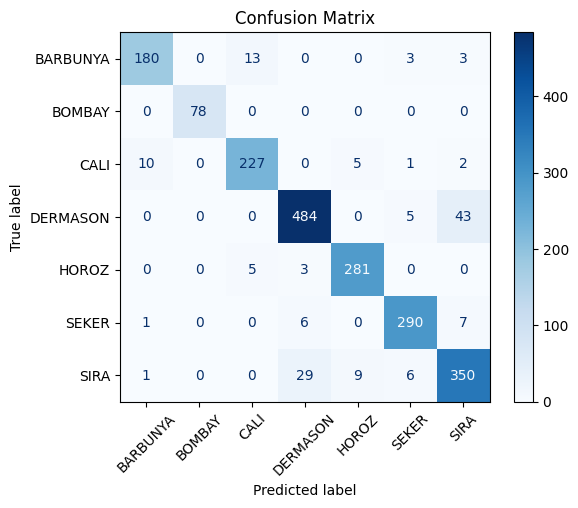

In [64]:
# =========================================
# 18. TEST NO DROPOUT
# =========================================

print("===== NO DROPOUT =====")

evaluate_model(
    model_no_dropout,
    X_test,
    y_test
)

ĐÁNH GIÁ DROPOUT

===== DROPOUT =====

Accuracy: 0.9251

Classification Report:

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.92       199
      BOMBAY       1.00      1.00      1.00        78
        CALI       0.93      0.92      0.93       245
    DERMASON       0.92      0.92      0.92       532
       HOROZ       0.95      0.97      0.96       289
       SEKER       0.95      0.95      0.95       304
        SIRA       0.87      0.88      0.87       395

    accuracy                           0.93      2042
   macro avg       0.94      0.94      0.94      2042
weighted avg       0.93      0.93      0.93      2042



<Figure size 1000x800 with 0 Axes>

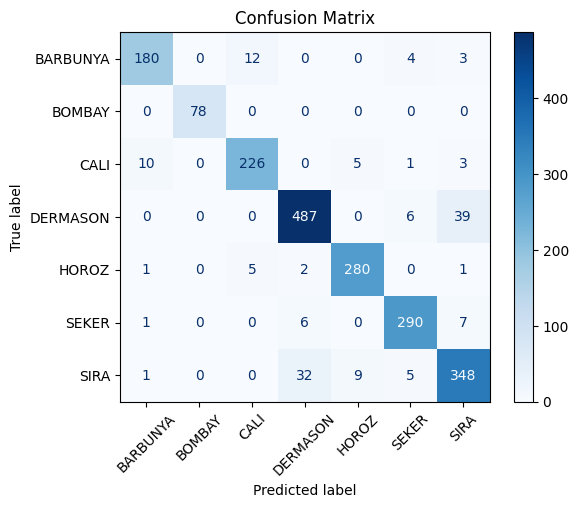

In [65]:
# =========================================
# 19. TEST DROPOUT
# =========================================

print("===== DROPOUT =====")

evaluate_model(
    model_dropout,
    X_test,
    y_test
)

KỊCH BẢN 3: KẾT HỢP DROPOUT VÀ SMOTE


>>> ĐANG CHẠY TRƯỜNG HỢP: NO SMOTE
Epoch 100/500 | Train Loss: 0.3119 | Val Loss: 0.2588 | Val Acc: 0.9089
Epoch 200/500 | Train Loss: 0.2245 | Val Loss: 0.2034 | Val Acc: 0.9256
Epoch 300/500 | Train Loss: 0.2125 | Val Loss: 0.1989 | Val Acc: 0.9275
Epoch 400/500 | Train Loss: 0.1965 | Val Loss: 0.1961 | Val Acc: 0.9280
Epoch 500/500 | Train Loss: 0.1886 | Val Loss: 0.1944 | Val Acc: 0.9285

==================== BÁO CÁO: BASELINE (NO SMOTE) ====================
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       199
           1       1.00      1.00      1.00        78
           2       0.93      0.93      0.93       245
           3       0.92      0.92      0.92       532
           4       0.95      0.97      0.96       289
           5       0.95      0.95      0.95       304
           6       0.87      0.88      0.88       395

    accuracy                           0.93      2042
   macro avg       0.94      0.93      0.94 

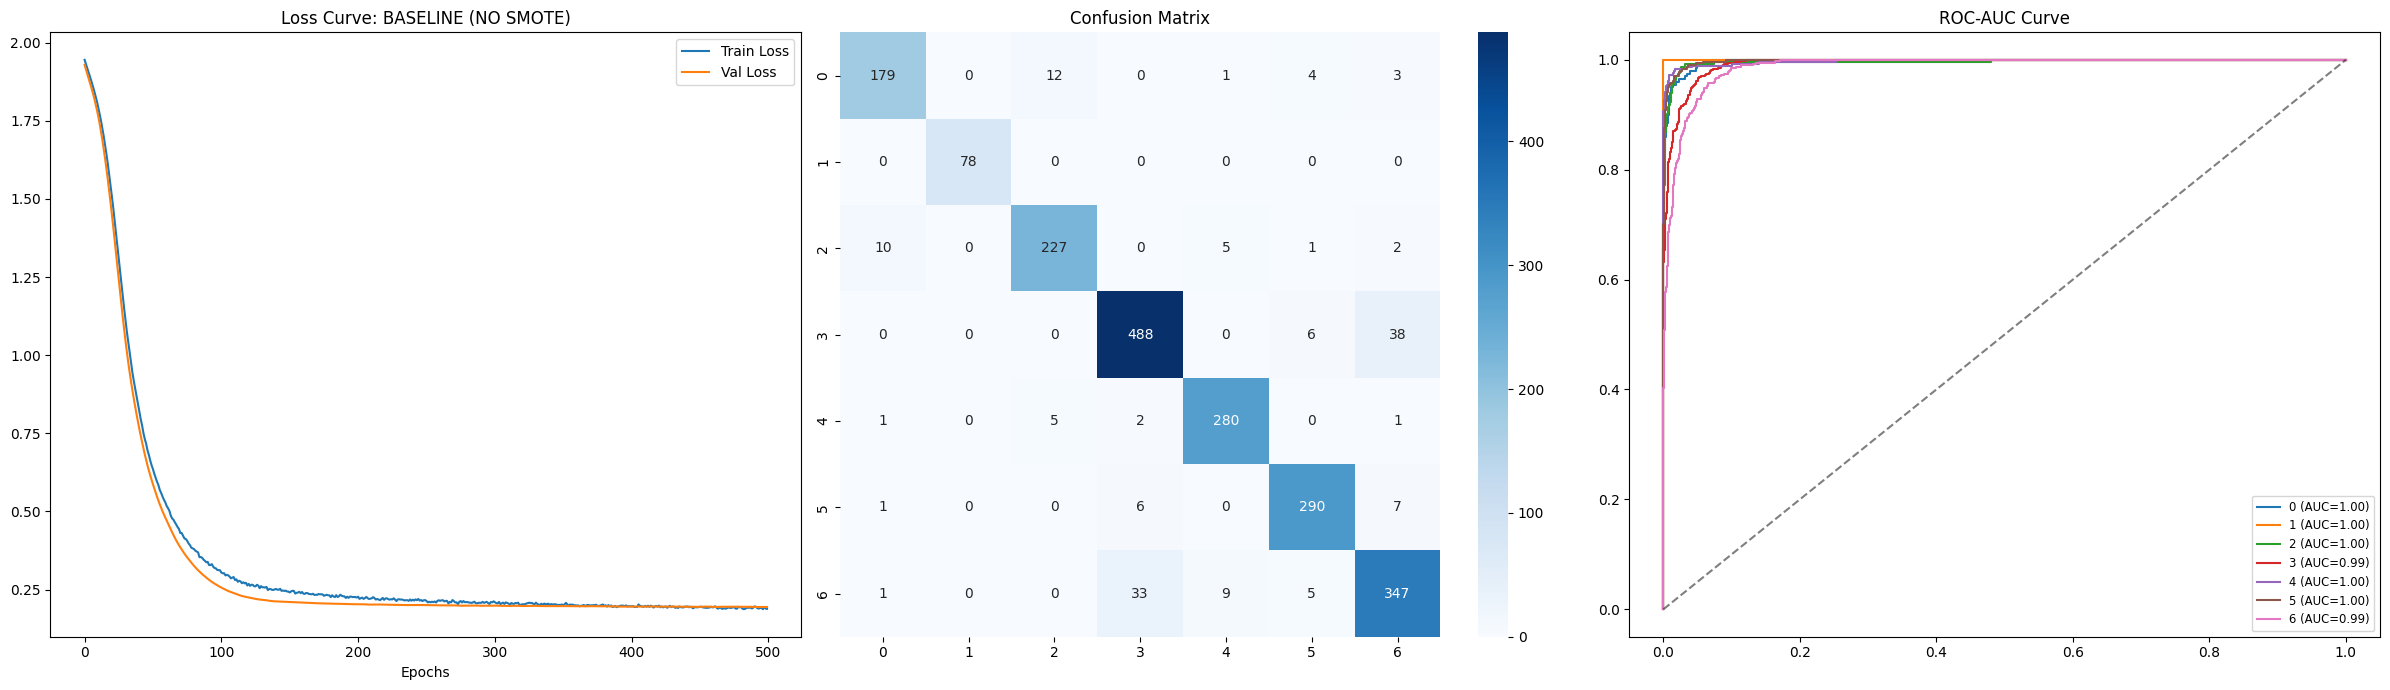


>>> ĐANG CHẠY TRƯỜNG HỢP: WITH SMOTE
Epoch 100/500 | Train Loss: 0.2358 | Val Loss: 0.2538 | Val Acc: 0.9104
Epoch 200/500 | Train Loss: 0.1723 | Val Loss: 0.2097 | Val Acc: 0.9251
Epoch 300/500 | Train Loss: 0.1600 | Val Loss: 0.2047 | Val Acc: 0.9270
Epoch 400/500 | Train Loss: 0.1514 | Val Loss: 0.2028 | Val Acc: 0.9300
Epoch 500/500 | Train Loss: 0.1446 | Val Loss: 0.2012 | Val Acc: 0.9275

==================== BÁO CÁO: SMOTE BALANCED ====================
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       199
           1       1.00      1.00      1.00        78
           2       0.92      0.92      0.92       245
           3       0.93      0.89      0.91       532
           4       0.94      0.97      0.96       289
           5       0.95      0.96      0.95       304
           6       0.84      0.89      0.87       395

    accuracy                           0.92      2042
   macro avg       0.93      0.93      0.93    

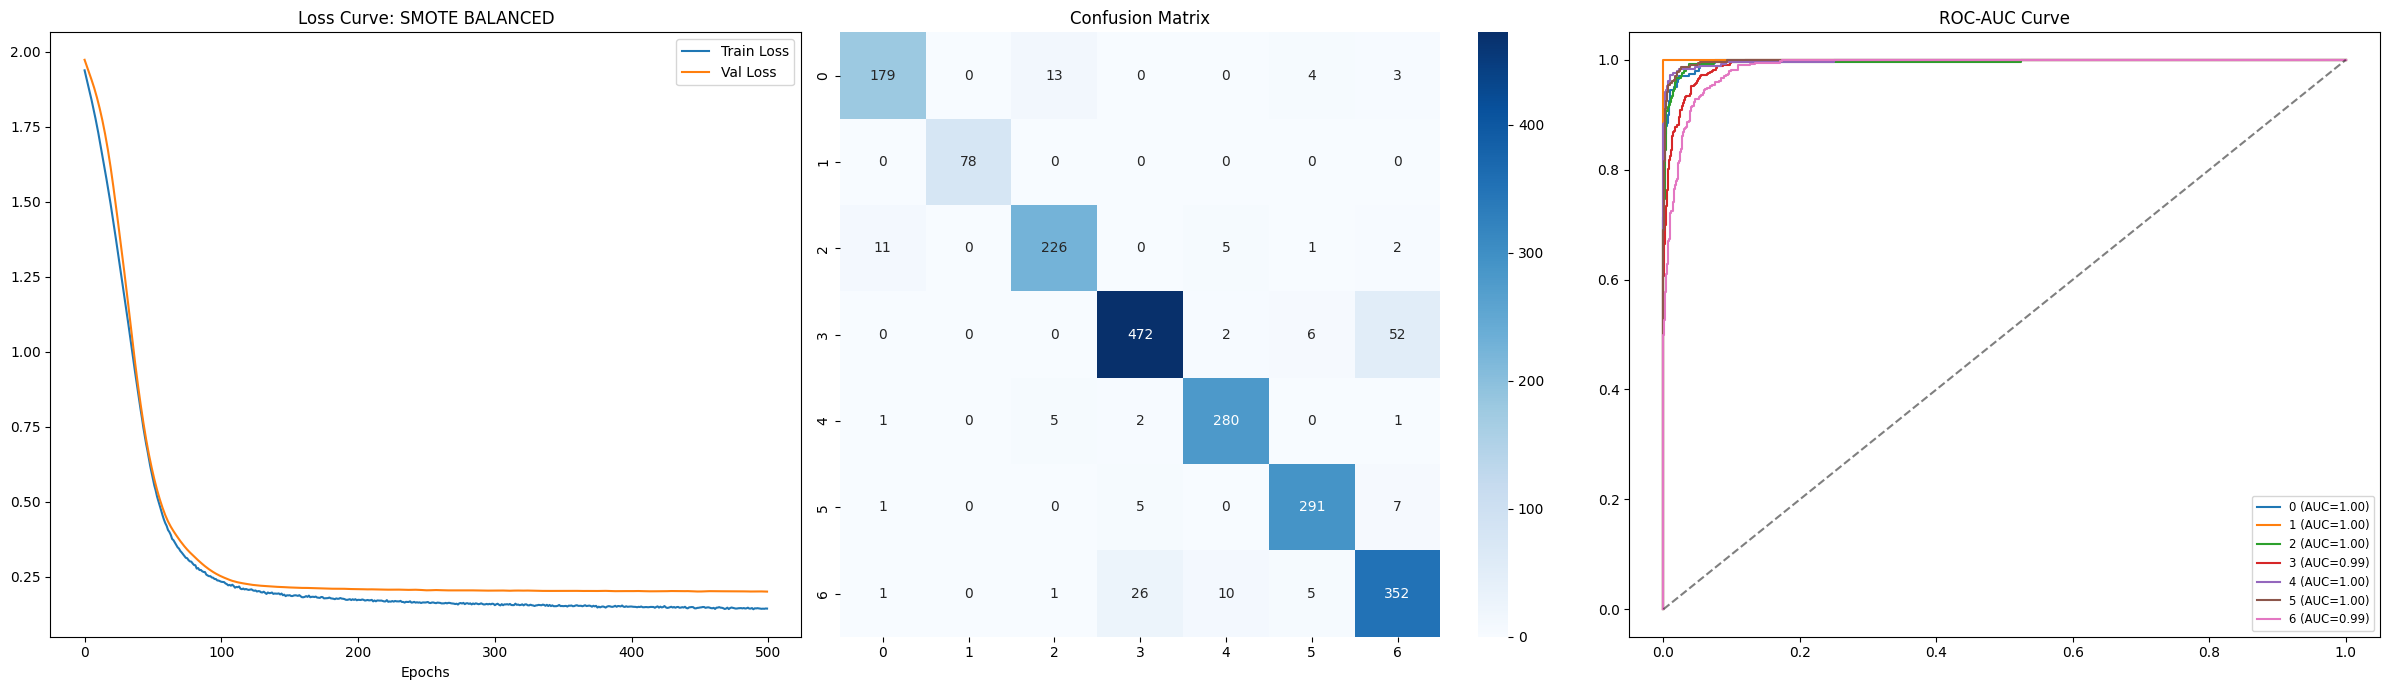

In [66]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

# =========================================
# 1. KIẾN TRÚC MÔ HÌNH MLP (128-64-32)
# =========================================
class DryBeanMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(DryBeanMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3), # Chống overfitting
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# =========================================
# 2. HÀM TRAIN
# =========================================
def train_model(model, X_train, y_train, X_val, y_val, epochs=500):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        # TRAIN PHASE
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        _, predicted = torch.max(outputs, 1)
        train_acc = (predicted == y_train).float().mean()
        train_accuracies.append(train_acc.item())

        # VALIDATION PHASE
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_losses.append(val_loss.item())
            _, val_predicted = torch.max(val_outputs, 1)
            val_acc = (val_predicted == y_val).float().mean()
            val_accuracies.append(val_acc.item())

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc.item():.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies

# =========================================
# 3. CHUẨN BỊ DỮ LIỆU (70/15/15)
# =========================================

X = pd_train.drop('Class', axis=1).values
le = LabelEncoder()
y = le.fit_transform(pd_train['Class'])

# Ép kiểu tên lớp thành chuỗi để tránh lỗi hiển thị Report
classes = [str(c) for c in le.classes_]

# Chia 70% train - 30% còn lại
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# Chia 30% còn lại thành 15% val - 15% test
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Chuẩn hóa
scaler = StandardScaler()
X_train_sc = torch.FloatTensor(scaler.fit_transform(X_train_raw))
X_val_sc = torch.FloatTensor(scaler.transform(X_val_raw))
X_test_sc = torch.FloatTensor(scaler.transform(X_test_raw))

y_train_t = torch.LongTensor(y_train_raw)
y_val_t = torch.LongTensor(y_val_raw)
y_test_t = torch.LongTensor(y_test_raw)

# SMOTE cho tập Train
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_raw, y_train_raw)
X_train_smote_sc = torch.FloatTensor(scaler.transform(X_res))
y_train_smote_t = torch.LongTensor(y_res)

# =========================================
# 4. HÀM HIỂN THỊ KẾT QUẢ TỔNG HỢP
# =========================================
def visualize_results(model, history, X_test, y_test, title):
    model.eval()
    with torch.no_grad():
        logits = model(X_test)
        probs = torch.softmax(logits, dim=1).numpy()
        preds = torch.argmax(logits, dim=1).numpy()

    print(f"\n{'='*20} BÁO CÁO: {title} {'='*20}")
    # Sử dụng danh sách classes đã được ép kiểu string
    print(classification_report(y_test.numpy(), preds, target_names=classes))

    fig, ax = plt.subplots(1, 3, figsize=(24, 7))

    # A. Biểu đồ Loss
    ax[0].plot(history[0], label='Train Loss')
    ax[0].plot(history[1], label='Val Loss')
    ax[0].set_title(f'Loss Curve: {title}')
    ax[0].set_xlabel('Epochs')
    ax[0].legend()

    # B. Ma trận nhầm lẫn
    cm = confusion_matrix(y_test.numpy(), preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax[1])
    ax[1].set_title('Confusion Matrix')

    # C. Đường cong ROC-AUC
    y_test_bin = label_binarize(y_test.numpy(), classes=range(len(classes)))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        score = auc(fpr, tpr)
        ax[2].plot(fpr, tpr, label=f'{classes[i]} (AUC={score:.2f})')

    ax[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax[2].set_title('ROC-AUC Curve')
    ax[2].legend(loc='lower right', fontsize='small')

    plt.tight_layout()
    plt.show()

# =========================================
# 5. THỰC THI
# =========================================
input_dim = X_train_raw.shape[1]
n_classes = len(classes)

print("\n>>> ĐANG CHẠY TRƯỜNG HỢP: NO SMOTE")
model_no = DryBeanMLP(input_dim, n_classes)
history_no = train_model(model_no, X_train_sc, y_train_t, X_val_sc, y_val_t, epochs=500)
visualize_results(model_no, history_no, X_test_sc, y_test_t, "BASELINE (NO SMOTE)")

print("\n>>> ĐANG CHẠY TRƯỜNG HỢP: WITH SMOTE")
model_sm = DryBeanMLP(input_dim, n_classes)
history_sm = train_model(model_sm, X_train_smote_sc, y_train_smote_t, X_val_sc, y_val_t, epochs=500)
visualize_results(model_sm, history_sm, X_test_sc, y_test_t, "SMOTE BALANCED")


>>> ĐANG CHẠY TRƯỜNG HỢP: NO SMOTE
Epoch 100/500 | Train Loss: 0.2978 | Val Loss: 0.2565 | Val Acc: 0.9089
Epoch 200/500 | Train Loss: 0.2289 | Val Loss: 0.2070 | Val Acc: 0.9241
Epoch 300/500 | Train Loss: 0.2122 | Val Loss: 0.2025 | Val Acc: 0.9270
Epoch 400/500 | Train Loss: 0.2000 | Val Loss: 0.1999 | Val Acc: 0.9261
Epoch 500/500 | Train Loss: 0.1913 | Val Loss: 0.1976 | Val Acc: 0.9261

==================== BÁO CÁO: BASELINE (NO SMOTE) ====================
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       199
           1       1.00      1.00      1.00        78
           2       0.93      0.93      0.93       245
           3       0.92      0.91      0.92       532
           4       0.95      0.97      0.96       289
           5       0.95      0.95      0.95       304
           6       0.87      0.88      0.87       395

    accuracy                           0.92      2042
   macro avg       0.94      0.93      0.94 

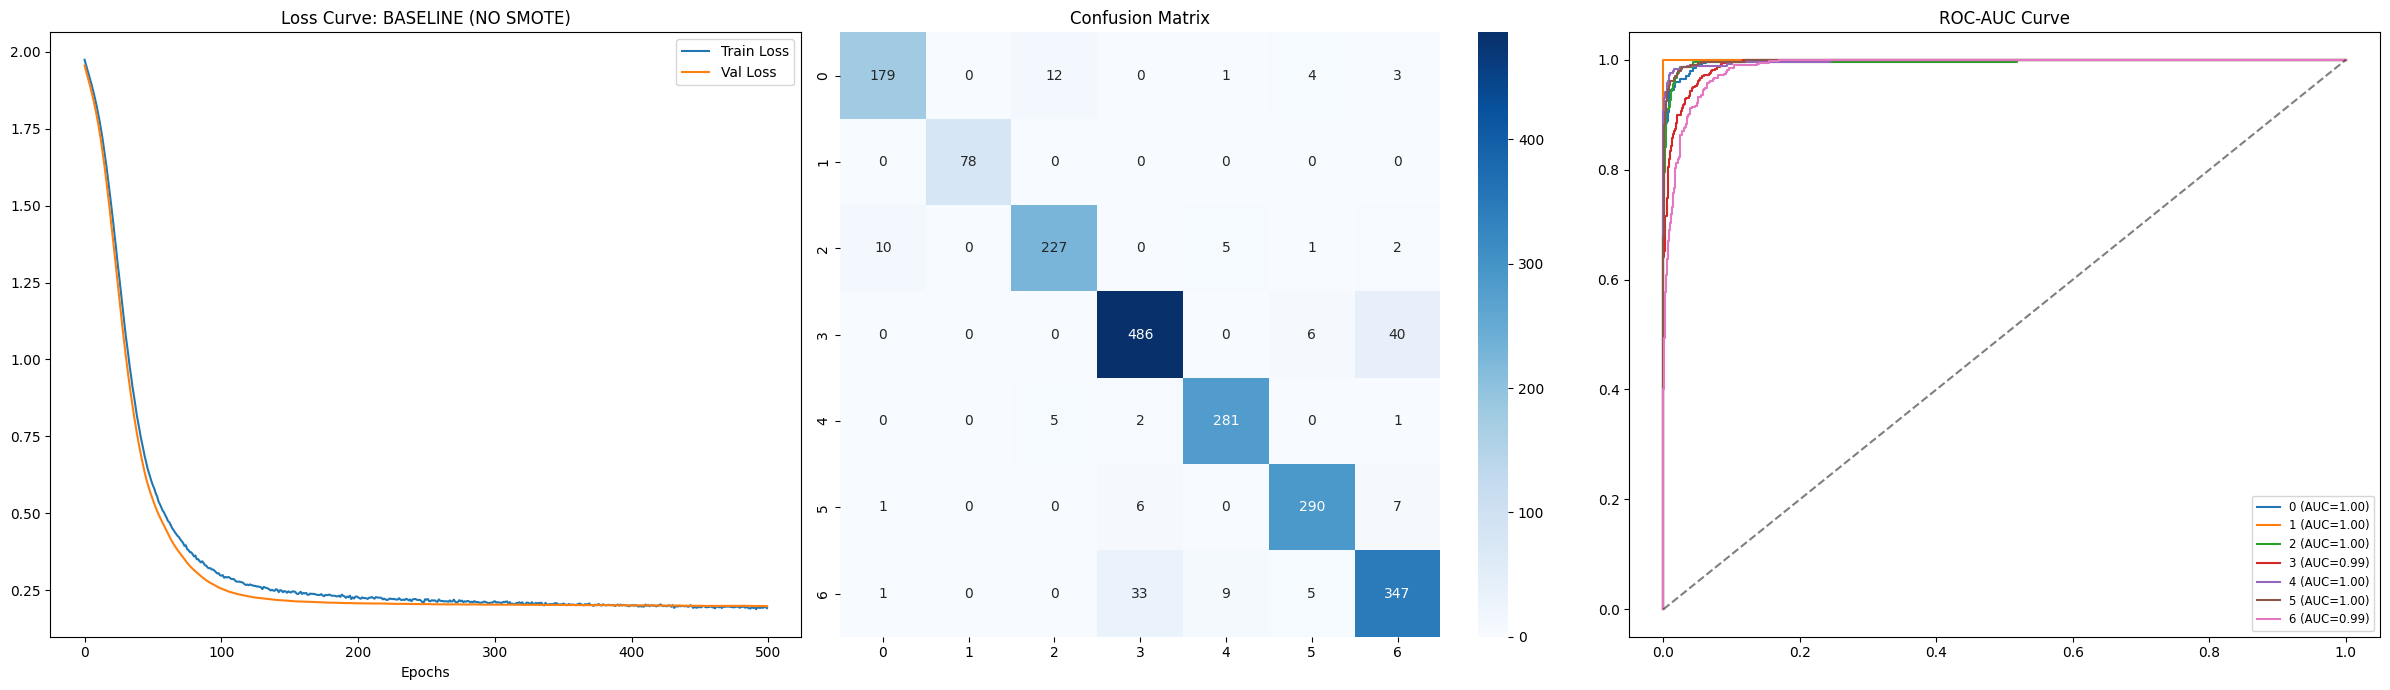


>>> ĐANG CHẠY TRƯỜNG HỢP: WITH SMOTE
Epoch 100/500 | Train Loss: 0.2355 | Val Loss: 0.2528 | Val Acc: 0.9079
Epoch 200/500 | Train Loss: 0.1720 | Val Loss: 0.2039 | Val Acc: 0.9246
Epoch 300/500 | Train Loss: 0.1576 | Val Loss: 0.2003 | Val Acc: 0.9280
Epoch 400/500 | Train Loss: 0.1488 | Val Loss: 0.1985 | Val Acc: 0.9270
Epoch 500/500 | Train Loss: 0.1442 | Val Loss: 0.1981 | Val Acc: 0.9285

==================== BÁO CÁO: SMOTE BALANCED ====================
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       199
           1       1.00      1.00      1.00        78
           2       0.93      0.93      0.93       245
           3       0.94      0.89      0.91       532
           4       0.94      0.97      0.95       289
           5       0.95      0.96      0.95       304
           6       0.85      0.90      0.87       395

    accuracy                           0.92      2042
   macro avg       0.93      0.94      0.93    

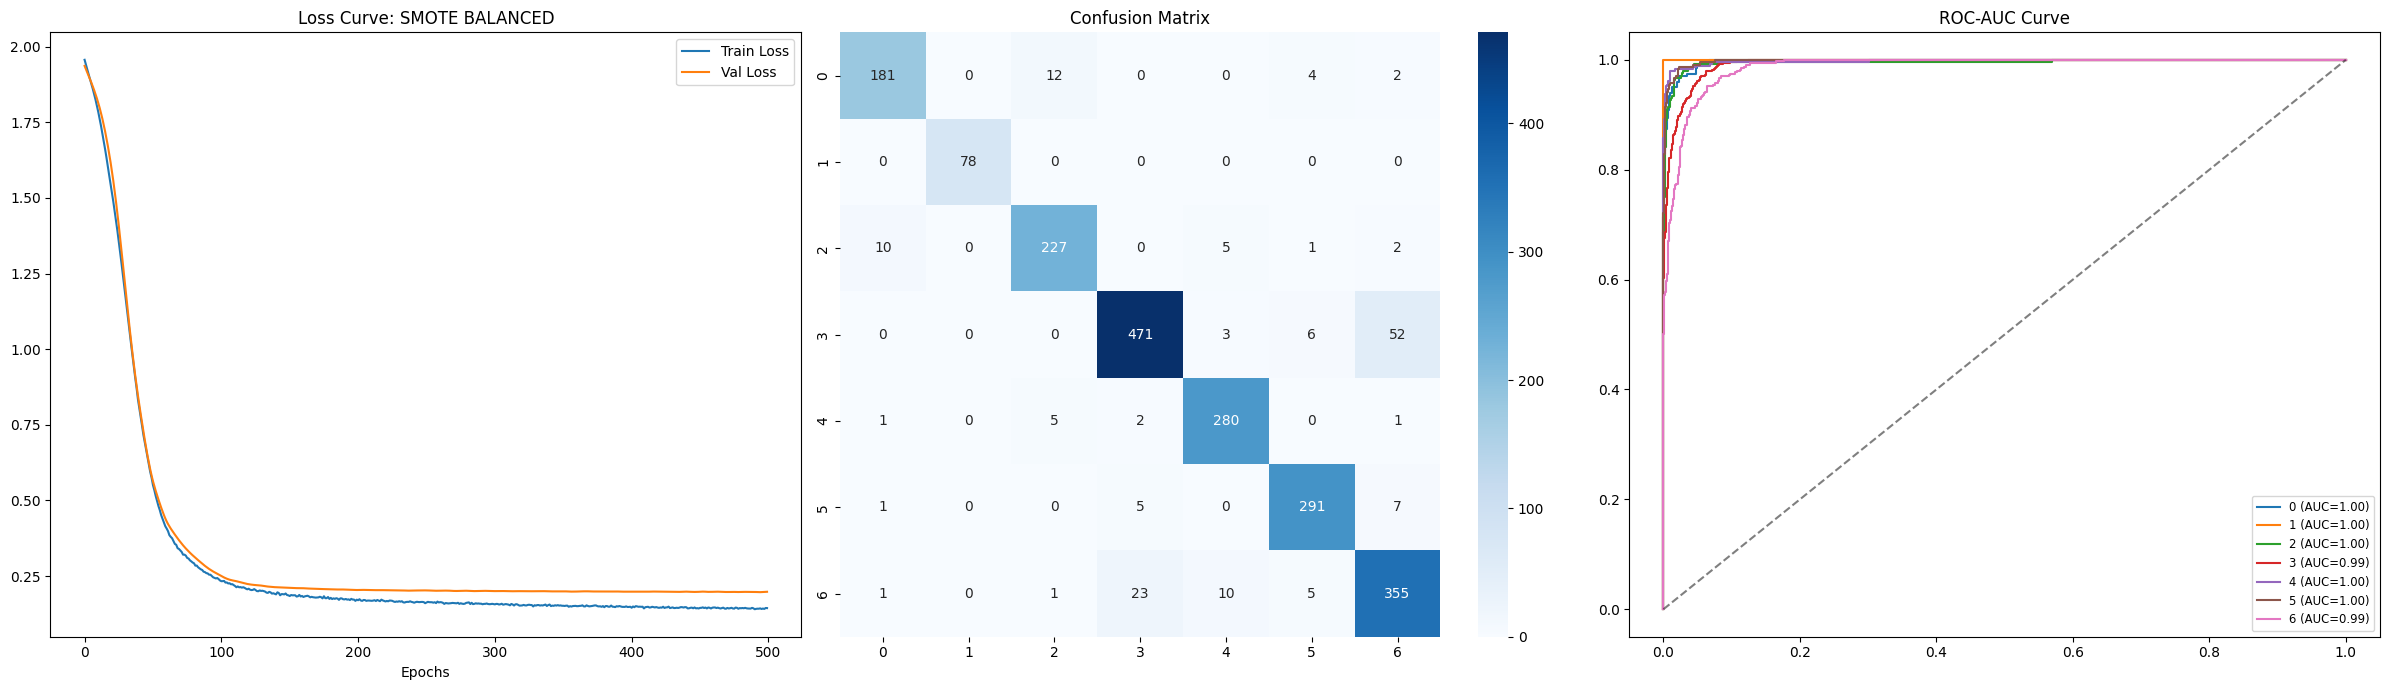

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

# =========================================
# 1. KIẾN TRÚC MÔ HÌNH MLP (128-64-32)
# =========================================
class DryBeanMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(DryBeanMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3), # Chống overfitting
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# =========================================
# 2. HÀM TRAIN
# =========================================
def train_model(model, X_train, y_train, X_val, y_val, epochs=500):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        # TRAIN PHASE
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        _, predicted = torch.max(outputs, 1)
        train_acc = (predicted == y_train).float().mean()
        train_accuracies.append(train_acc.item())

        # VALIDATION PHASE
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_losses.append(val_loss.item())
            _, val_predicted = torch.max(val_outputs, 1)
            val_acc = (val_predicted == y_val).float().mean()
            val_accuracies.append(val_acc.item())

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc.item():.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies

# =========================================
# 3. CHUẨN BỊ DỮ LIỆU (70/15/15)
# =========================================

X = pd_train.drop('Class', axis=1).values
le = LabelEncoder()
y = le.fit_transform(pd_train['Class'])

# Ép kiểu tên lớp thành chuỗi để tránh lỗi hiển thị Report
classes = [str(c) for c in le.classes_]

# Chia 70% train - 30% còn lại
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# Chia 30% còn lại thành 15% val - 15% test
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Chuẩn hóa
scaler = StandardScaler()
X_train_sc = torch.FloatTensor(scaler.fit_transform(X_train_raw))
X_val_sc = torch.FloatTensor(scaler.transform(X_val_raw))
X_test_sc = torch.FloatTensor(scaler.transform(X_test_raw))

y_train_t = torch.LongTensor(y_train_raw)
y_val_t = torch.LongTensor(y_val_raw)
y_test_t = torch.LongTensor(y_test_raw)

# SMOTE cho tập Train
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_raw, y_train_raw)
X_train_smote_sc = torch.FloatTensor(scaler.transform(X_res))
y_train_smote_t = torch.LongTensor(y_res)

# =========================================
# 4. HÀM HIỂN THỊ KẾT QUẢ TỔNG HỢP
# =========================================
def visualize_results(model, history, X_test, y_test, title):
    model.eval()
    with torch.no_grad():
        logits = model(X_test)
        probs = torch.softmax(logits, dim=1).numpy()
        preds = torch.argmax(logits, dim=1).numpy()

    print(f"\n{'='*20} BÁO CÁO: {title} {'='*20}")
    # Sử dụng danh sách classes đã được ép kiểu string
    print(classification_report(y_test.numpy(), preds, target_names=classes))

    fig, ax = plt.subplots(1, 3, figsize=(24, 7))

    # A. Biểu đồ Loss
    ax[0].plot(history[0], label='Train Loss')
    ax[0].plot(history[1], label='Val Loss')
    ax[0].set_title(f'Loss Curve: {title}')
    ax[0].set_xlabel('Epochs')
    ax[0].legend()

    # B. Ma trận nhầm lẫn
    cm = confusion_matrix(y_test.numpy(), preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax[1])
    ax[1].set_title('Confusion Matrix')

    # C. Đường cong ROC-AUC
    y_test_bin = label_binarize(y_test.numpy(), classes=range(len(classes)))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        score = auc(fpr, tpr)
        ax[2].plot(fpr, tpr, label=f'{classes[i]} (AUC={score:.2f})')

    ax[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax[2].set_title('ROC-AUC Curve')
    ax[2].legend(loc='lower right', fontsize='small')

    plt.tight_layout()
    plt.show()

# =========================================
# 5. THỰC THI
# =========================================
input_dim = X_train_raw.shape[1]
n_classes = len(classes)

print("\n>>> ĐANG CHẠY TRƯỜNG HỢP: NO SMOTE")
model_no = DryBeanMLP(input_dim, n_classes)
history_no = train_model(model_no, X_train_sc, y_train_t, X_val_sc, y_val_t, epochs=500)
visualize_results(model_no, history_no, X_test_sc, y_test_t, "BASELINE (NO SMOTE)")

print("\n>>> ĐANG CHẠY TRƯỜNG HỢP: WITH SMOTE")
model_sm = DryBeanMLP(input_dim, n_classes)
history_sm = train_model(model_sm, X_train_smote_sc, y_train_smote_t, X_val_sc, y_val_t, epochs=500)
visualize_results(model_sm, history_sm, X_test_sc, y_test_t, "SMOTE BALANCED")